# GRU Training Results Viewer

Run all cells, then select an experiment from the dropdown. The viewer contains only training convergence and validation prediction quality.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import Markdown, display, clear_output

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
print("Project root:", PROJECT_ROOT)

Project root: D:\硕士论文\Project_vision1


In [2]:
def discover_experiments():
    records = []
    experiments_dir = PROJECT_ROOT / "results" / "kelmarsh" / "experiments"
    for metadata_path in experiments_dir.glob("*/metadata.json"):
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        paths = {key: PROJECT_ROOT / value for key, value in metadata["paths"].items()}
        if paths["train_log"].exists() and paths["predictions"].exists():
            records.append({
                "label": f"{metadata['run_id']} | best epoch {metadata['best_epoch']}",
                "created_at": metadata.get("created_at", ""),
                "metadata": metadata,
                "log_path": paths["train_log"],
                "prediction_path": paths["predictions"],
                "x_scaler_path": paths.get("x_scaler"),
                "y_scaler_path": paths.get("y_scaler"),
            })

    legacy_log = PROJECT_ROOT / "results" / "kelmarsh" / "logs" / "kelmarsh_1_train_log.csv"
    legacy_pred = PROJECT_ROOT / "results" / "kelmarsh" / "predictions" / "kelmarsh_1_healthy_val_predictions.csv"
    legacy_scaler = PROJECT_ROOT / "models" / "kelmarsh" / "scalers" / "kelmarsh_1_y_scaler.pkl"
    if legacy_log.exists() and legacy_pred.exists():
        legacy_epochs = int(pd.read_csv(legacy_log)["epoch"].max())
        records.append({
            "label": f"Legacy Kelmarsh_1 | {legacy_epochs} epochs",
            "created_at": "0000",
            "metadata": {"run_id": "legacy_kelmarsh_1", "epochs_requested": legacy_epochs},
            "log_path": legacy_log,
            "prediction_path": legacy_pred,
            "x_scaler_path": None,
            "y_scaler_path": legacy_scaler if legacy_scaler.exists() else None,
        })
    return sorted(records, key=lambda record: record["created_at"], reverse=True)

experiments = discover_experiments()
if not experiments:
    raise FileNotFoundError("No completed experiment results were found.")
print(f"Found {len(experiments)} experiment(s).")

Found 3 experiment(s).


In [3]:
def inverse_standardized_feature(values, scaler, index):
    if hasattr(scaler, "mean_"):
        return values * scaler.scale_[index] + scaler.mean_[index]
    if hasattr(scaler, "center_"):
        return values * scaler.scale_[index] + scaler.center_[index]
    raise TypeError("Unsupported scaler type for automatic unit restoration.")

def restore_physical_units(pred, record):
    y_true = pred["y_true"].to_numpy()
    y_pred = pred["y_pred"].to_numpy()
    if pred["y_true"].abs().quantile(0.95) >= 10:
        return y_true, y_pred

    if record["x_scaler_path"] is not None:
        scaler = joblib.load(record["x_scaler_path"])
        feature_names = list(scaler.feature_names_in_)
        target = record["metadata"]["target"]
        target_index = feature_names.index(target)
        return (
            inverse_standardized_feature(y_true, scaler, target_index),
            inverse_standardized_feature(y_pred, scaler, target_index),
        )

    if record["y_scaler_path"] is not None:
        scaler = joblib.load(record["y_scaler_path"])
        return scaler.inverse_transform(y_true.reshape(-1, 1)).ravel(), scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    return y_true, y_pred

def render_experiment(record):
    train_log = pd.read_csv(record["log_path"])
    pred = pd.read_csv(record["prediction_path"], parse_dates=["Date and time"])
    best_row = train_log.loc[train_log["val_loss"].idxmin()]

    y_true, y_pred = restore_physical_units(pred, record)
    pred = pred.assign(y_true_plot=y_true, y_pred_plot=y_pred)

    display(pd.DataFrame({
        "Experiment": [record["metadata"]["run_id"]],
        "Epochs requested": [record["metadata"].get("epochs_requested", int(train_log["epoch"].max()))],
        "Epochs completed": [int(train_log["epoch"].max())],
        "Best epoch": [int(best_row["epoch"])],
        "Best validation loss": [best_row["val_loss"]],
        "Prediction samples": [len(pred)],
    }))

    display(Markdown("### Training convergence"))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
    for ax in axes:
        ax.plot(train_log["epoch"], train_log["train_loss"], marker="o", ms=3, label="Training")
        ax.plot(train_log["epoch"], train_log["val_loss"], marker="o", ms=3, label="Validation")
        ax.axvline(best_row["epoch"], color="black", ls="--", lw=1, label=f"Best epoch = {int(best_row['epoch'])}")
        ax.set(xlabel="Epoch", ylabel="MSE loss")
        ax.legend()
    axes[0].set_title("Loss convergence")
    axes[1].set_yscale("log")
    axes[1].set_title("Loss convergence (log scale)")
    fig.tight_layout()
    plt.show()

    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    r2 = 1 - np.sum(error ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    bias = np.mean(error)
    display(Markdown("### Prediction quality"))
    display(pd.DataFrame({"MAE (deg C)": [mae], "RMSE (deg C)": [rmse], "R-squared": [r2], "Bias (deg C)": [bias]}))

    plot_df = pred.sort_values("Date and time")
    if "segment_id" in plot_df.columns:
        largest_segment = plot_df.groupby("segment_id").size().idxmax()
        example = plot_df[plot_df["segment_id"] == largest_segment].head(500)
        example_name = f"segment {largest_segment}"
    else:
        example = plot_df.head(500)
        example_name = "first 500 samples"

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].plot(example["Date and time"], example["y_true_plot"], label="Measured", lw=1.5)
    axes[0].plot(example["Date and time"], example["y_pred_plot"], label="Predicted", lw=1.2, alpha=0.85)
    axes[0].set(title=f"Example time series ({example_name})", xlabel="Time", ylabel="Temperature (deg C)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].legend()

    hb = axes[1].hexbin(y_true, y_pred, gridsize=45, mincnt=1, cmap="viridis")
    limits = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[1].plot(limits, limits, color="crimson", ls="--", lw=1.5, label="Ideal")
    axes[1].set(title=f"Measured vs predicted (R-squared = {r2:.3f})", xlabel="Measured (deg C)", ylabel="Predicted (deg C)", xlim=limits, ylim=limits)
    axes[1].legend()
    fig.colorbar(hb, ax=axes[1], label="Sample density")
    fig.tight_layout()
    plt.show()

In [4]:
experiment_dropdown = widgets.Dropdown(
    options=[(record["label"], index) for index, record in enumerate(experiments)],
    value=0,
    description="Experiment:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="95%"),
)
result_output = widgets.Output()

def update_view(change=None):
    with result_output:
        clear_output(wait=True)
        render_experiment(experiments[experiment_dropdown.value])

experiment_dropdown.observe(update_view, names="value")
display(experiment_dropdown, result_output)
update_view()

Dropdown(description='Experiment:', layout=Layout(width='95%'), options=(('kelmarsh_1_e60 | best epoch 50', 0)…

Output()

# Static experiment results

The following outputs are embedded so the 20-, 40-, and 60-epoch results remain visible when this notebook is viewed on GitHub.

## kelmarsh_1_e20 | best epoch 20

,Experiment,Epochs requested,Epochs completed,Best epoch,Best validation loss,Prediction samples
0,kelmarsh_1_e20,20,20,20,0.0034,54205


### Training convergence

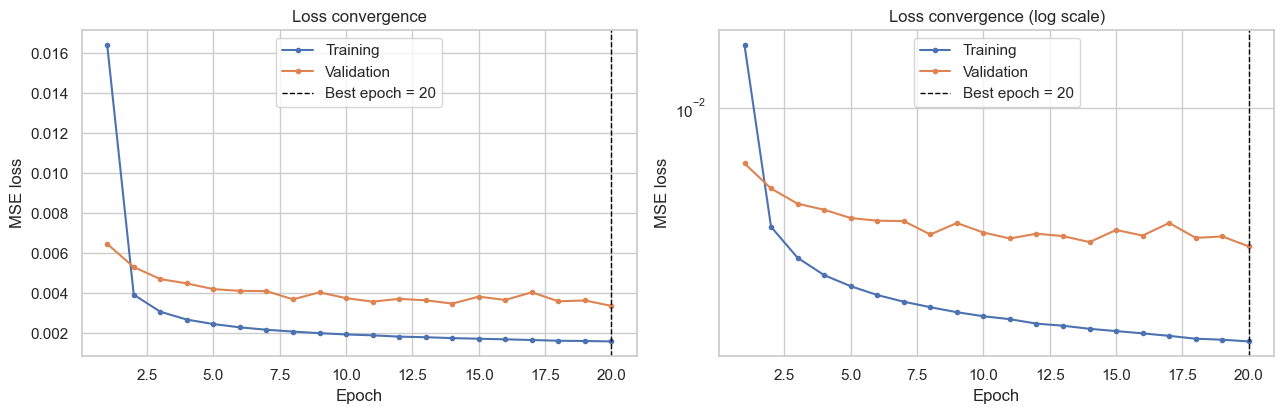

### Prediction quality

,MAE (deg C),RMSE (deg C),R-squared,Bias (deg C)
0,0.1587,0.3232,0.9969,0.0049


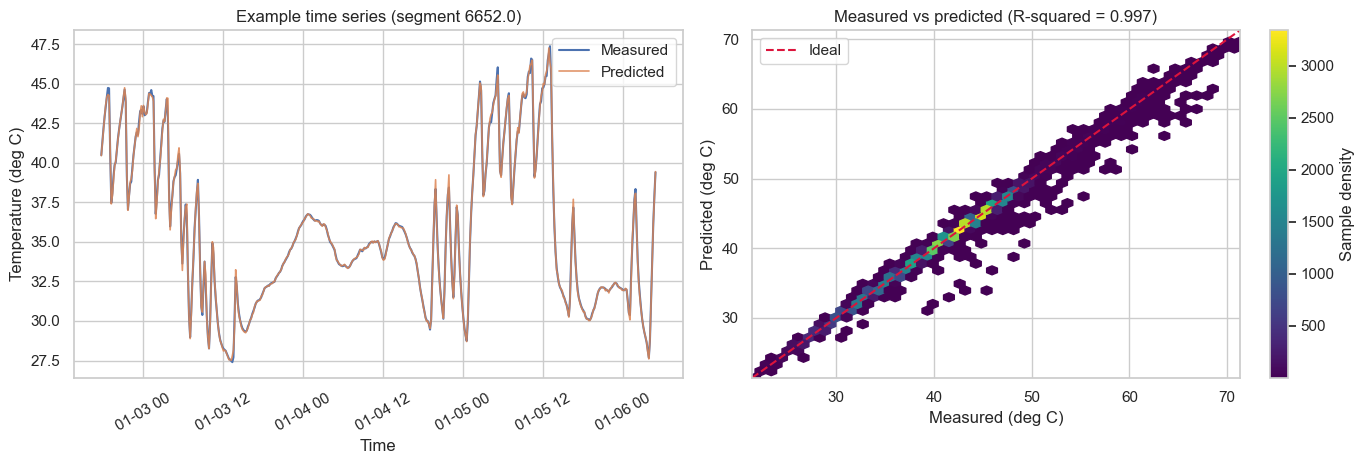

## kelmarsh_1_e40 | best epoch 38

,Experiment,Epochs requested,Epochs completed,Best epoch,Best validation loss,Prediction samples
0,kelmarsh_1_e40,40,40,38,0.0032,54205


### Training convergence

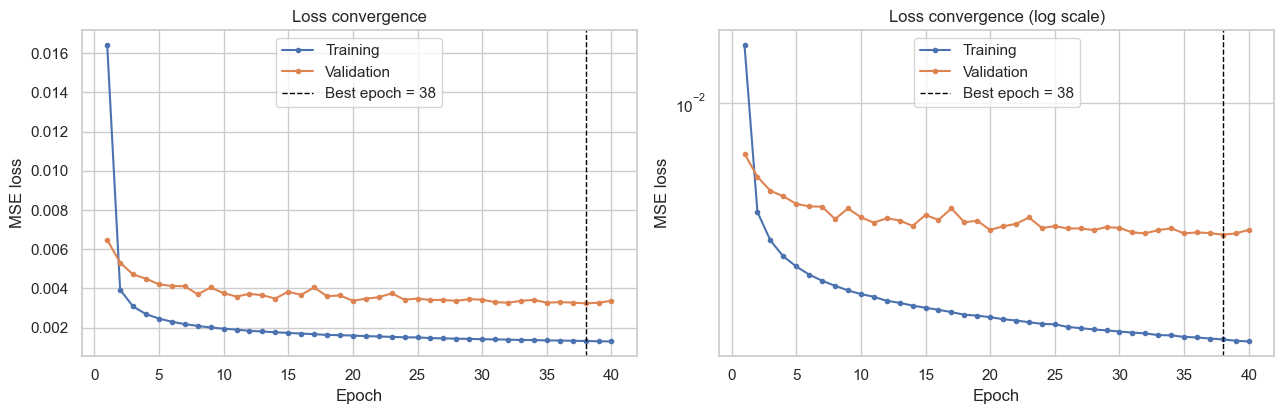

### Prediction quality

,MAE (deg C),RMSE (deg C),R-squared,Bias (deg C)
0,0.1573,0.3167,0.9970,-0.0318


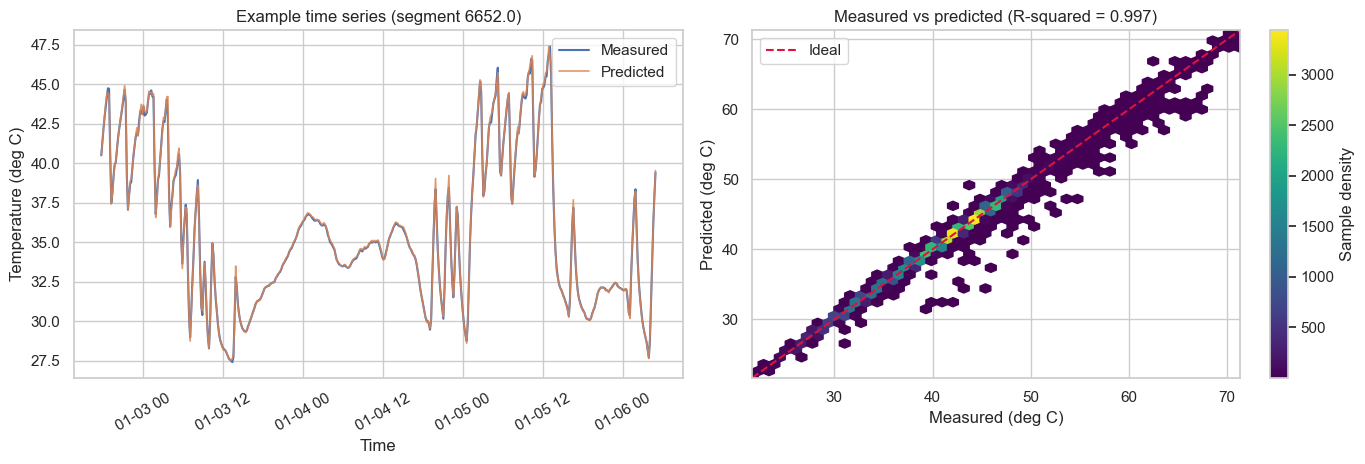

## kelmarsh_1_e60 | best epoch 50

,Experiment,Epochs requested,Epochs completed,Best epoch,Best validation loss,Prediction samples
0,kelmarsh_1_e60,60,60,50,0.0030,54205


### Training convergence

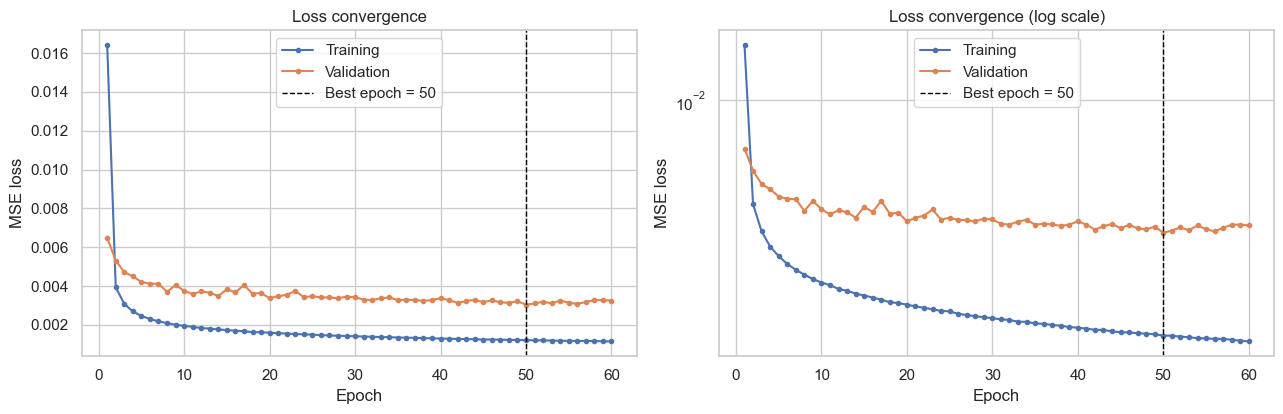

### Prediction quality

,MAE (deg C),RMSE (deg C),R-squared,Bias (deg C)
0,0.1528,0.3069,0.9972,0.0151


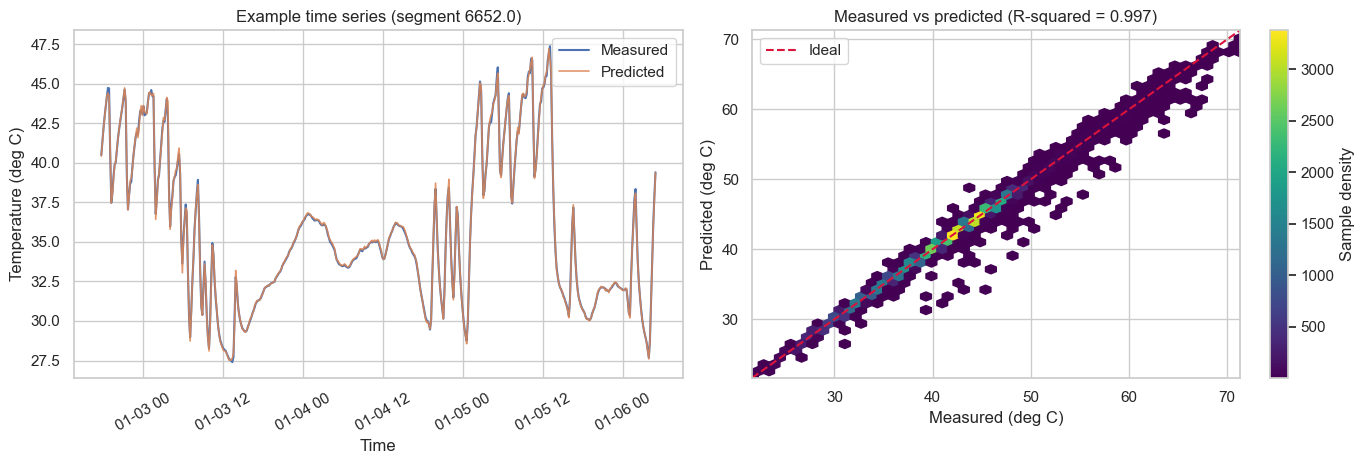

In [5]:
for record in sorted(experiments, key=lambda item: item["metadata"]["epochs_requested"]):
    display(Markdown(f"## {record['label']}"))
    render_experiment(record)